In [73]:
# Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [74]:
from IPython.display import HTML
display(HTML(filename='used_cars_infographic.html'))

In [75]:
# ==========================================
# 1 - Data Understanding
# ==========================================

In [76]:
import pandas as pd

data = pd.read_csv("used_cars.csv")
df = data.copy()

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [77]:
# Random Data
# بتعرض 5 سطور عشوائية عشان نتأكد إن الداتا كلها مقروءة صح
df.sample(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
960,Mercedes-Benz,AMG G 63 Base,2017,"73,000 mi.",Gasoline,563.0HP 5.5L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,"$78,000"
904,Cadillac,Escalade Luxury,2013,"95,570 mi.",E85 Flex Fuel,403.0HP 6.2L 8 Cylinder Engine Flex Fuel Capab...,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$22,000"
509,BMW,135 i,2008,"87,000 mi.",Gasoline,300.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,A/T,White,Beige,None reported,Yes,"$15,300"
2964,Hyundai,Kona EV SEL,2022,"9,400 mi.",NaN,201.0HP Electric Motor Electric Fuel System,1-Speed A/T,Red,Black,None reported,Yes,"$31,999"
2059,BMW,640 Gran Coupe i,2014,"39,886 mi.",Gasoline,315.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,Transmission w/Dual Shift Mode,Black,Red,At least 1 accident or damage reported,Yes,"$26,000"


In [78]:
# size of the dataset
# بتعرفك الداتا فيها كام سطر وكام عمود
df.shape

(4009, 12)

In [79]:
# Data Information
# مهمة جداً عشان تعرف إيه الأعمدة اللي فيها نصوص وإيه اللي فيها أرقام
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [80]:
# بتعرضلك لستة بأسماء كل الأعمدة الموجودة في الداتا
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [81]:
# Check Description of the dataset
# بتجيبلك المتوسط، الانحراف المعياري، أقل وأكبر قيمة لكل عمود رقمي
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model_year,4009.0,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0


In [82]:
# Number of unique values in each column
# بتعرفك كل عمود فيه كام قيمة مختلفة
df.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64

In [83]:
# Check Balance of a categorical column 
# استبدل 'Fuel_Type' باسم العمود المناسب في الداتا بتاعتك
df['fuel_type'].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [84]:
# Check Balance of the dataset in percentages
round(df['fuel_type'].value_counts(normalize=True)*100, 2)

fuel_type
Gasoline          86.19
Hybrid             5.05
E85 Flex Fuel      3.62
Diesel             3.02
–                  1.17
Plug-In Hybrid     0.89
not supported      0.05
Name: proportion, dtype: float64

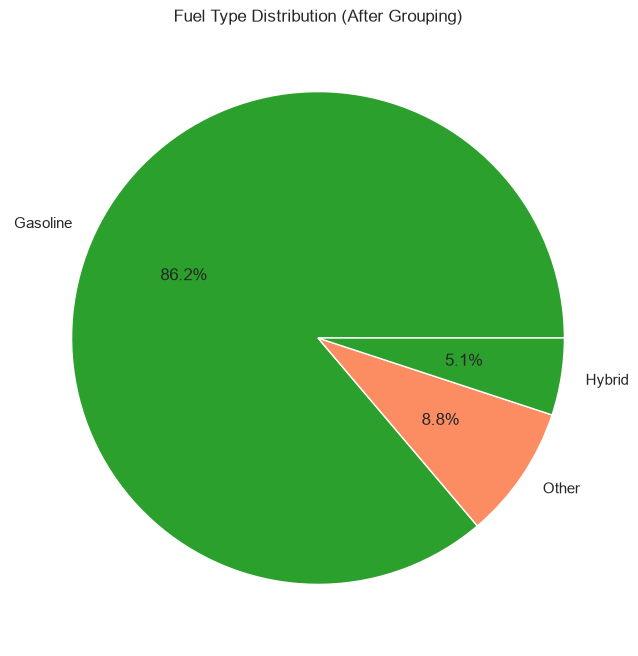

In [85]:
# ==========================================
# Handling Rare Categories in Features (Fuel Type)
# ==========================================

# 1. حساب نسبة كل نوع وقود في الداتا
fuel_percentages = df['fuel_type'].value_counts(normalize=True) * 100

# 2. تحديد الأنواع النادرة (اللي تمثل أقل من 5% من الداتا)
rare_fuels = fuel_percentages[fuel_percentages < 5].index

# 3. استبدال الأنواع النادرة بفئة واحدة اسمها 'Other'
df['fuel_type'] = df['fuel_type'].replace(rare_fuels, 'Other')

# 4. رسم الـ Pie Chart الجديد للتأكد من نجاح التجميع
plt.figure(figsize=(8, 8))
df['fuel_type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ca02c', '#fc8d62'])
plt.title('Fuel Type Distribution (After Grouping)')
plt.ylabel('') # عشان نشيل اسم العمود من على الجنب ويكون الشكل أنظف
plt.show()

In [86]:
 # ==========================================
# 2. DATA CLEANING & PREPROCESSING
# ==========================================

In [87]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [88]:
# 1. تنظيف عمود السعر (price)
# إزالة علامة الدولار والفاصلة، ثم تحويل العمود إلى أرقام
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 2. تنظيف عمود المسافة المقطوعة (milage)
# إزالة كلمة ' mi.' والفاصلة، ثم تحويل العمود إلى أرقام
df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False)
df['milage'] = df['milage'].str.replace(',', '', regex=False)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

# 3. معالجة القيم المفقودة (Missing Values)
# ملء الفراغات في نوع الوقود بالنوع الأكثر تكراراً (Mode)
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])

# ملء الفراغات في الحوادث وحالة السيارة بكلمة 'Unknown' لأنها بيانات نصية
df['accident'] = df['accident'].fillna('Unknown')
df['clean_title'] = df['clean_title'].fillna('Unknown')

# 4. حذف أي صفوف مكررة في البيانات
df = df.drop_duplicates()

# عرض النتيجة النهائية للتأكد من نجاح التنظيف
print("أول 5 صفوف بعد التنظيف:")
display(df.head())

print("\nمعلومات البيانات للتأكد من تحول الأعمدة إلى أرقام (float/int):")
df.info()

أول 5 صفوف بعد التنظيف:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999



معلومات البيانات للتأكد من تحول الأعمدة إلى أرقام (float/int):
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     4009 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      4009 non-null   str  
 10  clean_title   4009 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 376.0 KB


In [89]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [90]:
# 3. Detect and Remove Duplicate Rows
print("Duplicated rows:", df.duplicated().sum())
# if data is dublicated, we can remove it using the drop_duplicates() method.
#  df = df.drop_duplicates()

Duplicated rows: 0


In [91]:
# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

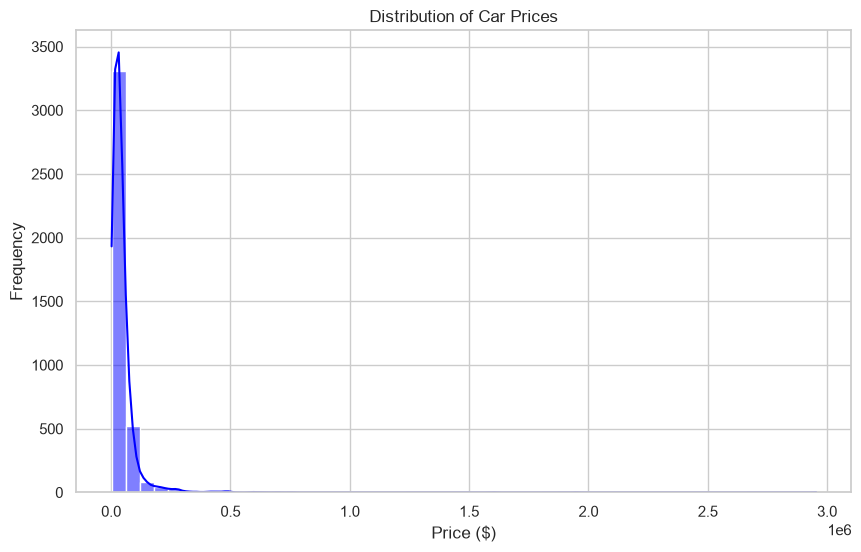

In [92]:
# 1. Distribution of Car Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

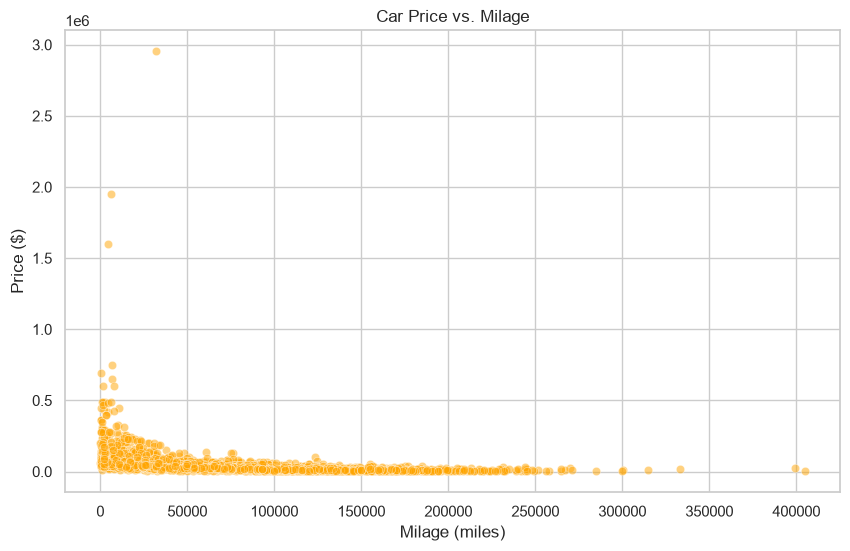

In [93]:
# 2. Scatter plot: Milage vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='milage', y='price', data=df, alpha=0.5, color='orange')
plt.title('Car Price vs. Milage')
plt.xlabel('Milage (miles)')
plt.ylabel('Price ($)')
plt.show()

C:\Users\Ziad\AppData\Local\Temp\ipykernel_296\2216020003.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel_type', y='price', data=df, palette='Set2')


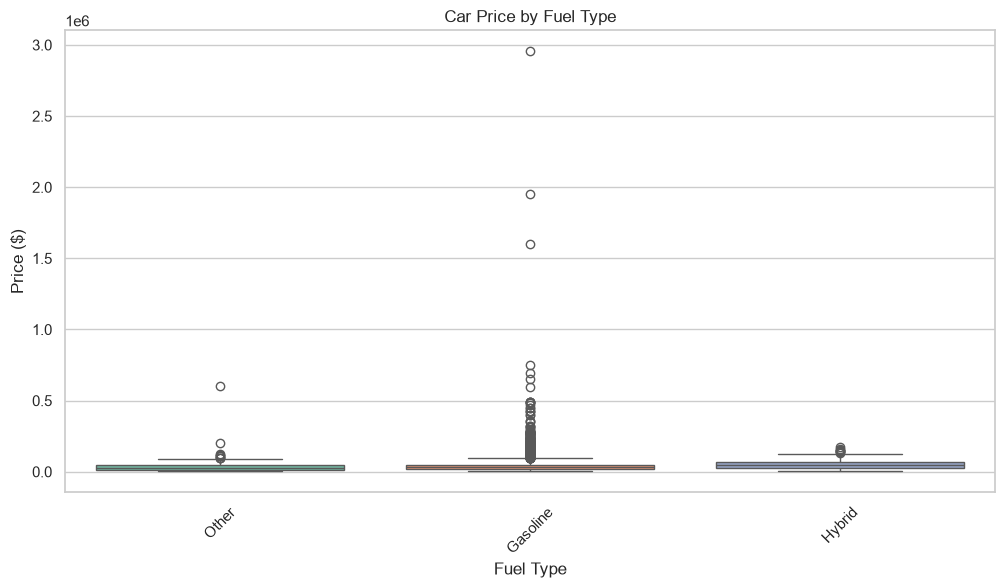

In [94]:
# 3. Boxplot: Fuel Type vs Price
plt.figure(figsize=(12, 6))
sns.boxplot(x='fuel_type', y='price', data=df, palette='Set2')
plt.title('Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45) # بنلف الكلام عشان لو أسامي الوقود طويلة ماتدخلش في بعضها
plt.show()

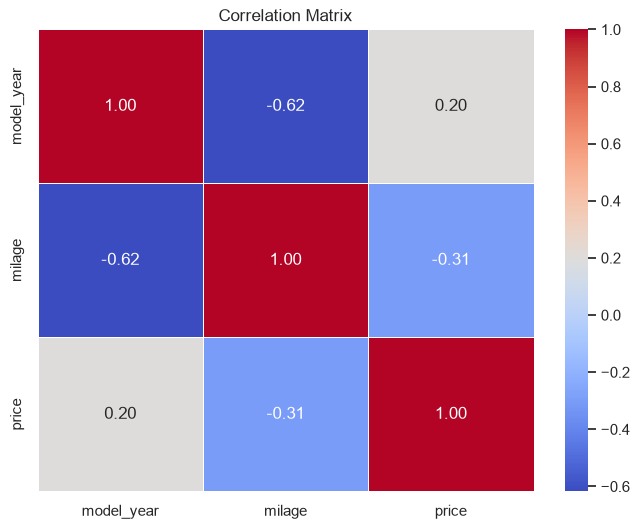

In [95]:
# 4. Correlation Heatmap
# بنختار الأعمدة الرقمية بس عشان نحسب الارتباط بينهم
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

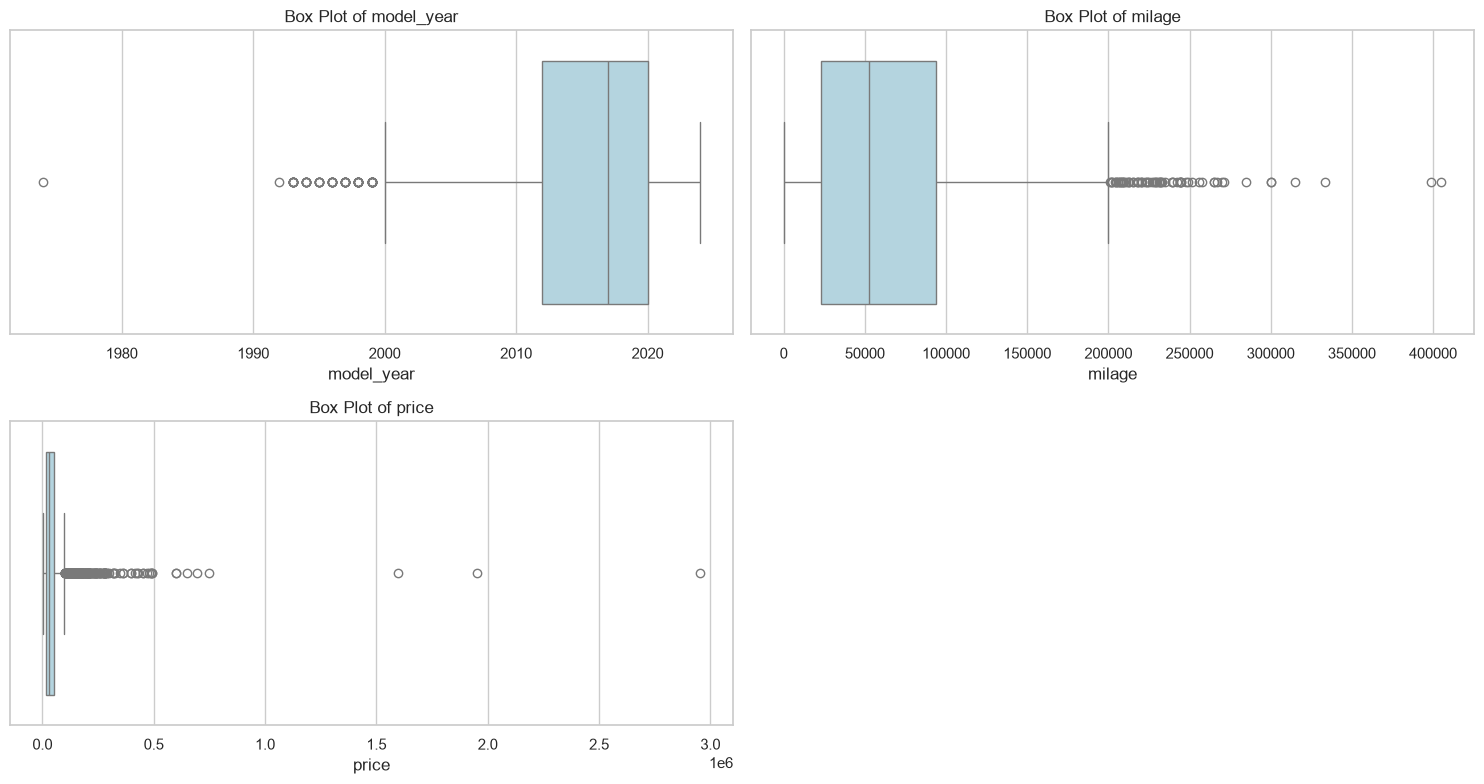

In [96]:
# 5. Check Outliers for all numeric columns
import math

# Extract numeric columns only
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

cols = 2
rows = math.ceil(len(num_cols) / cols) 

plt.figure(figsize=(15, rows * 4))

for i, feature in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[feature], color='lightblue')
    plt.title(f"Box Plot of {feature}")

plt.tight_layout()
plt.show()

C:\Users\Ziad\AppData\Local\Temp\ipykernel_296\1219302259.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')


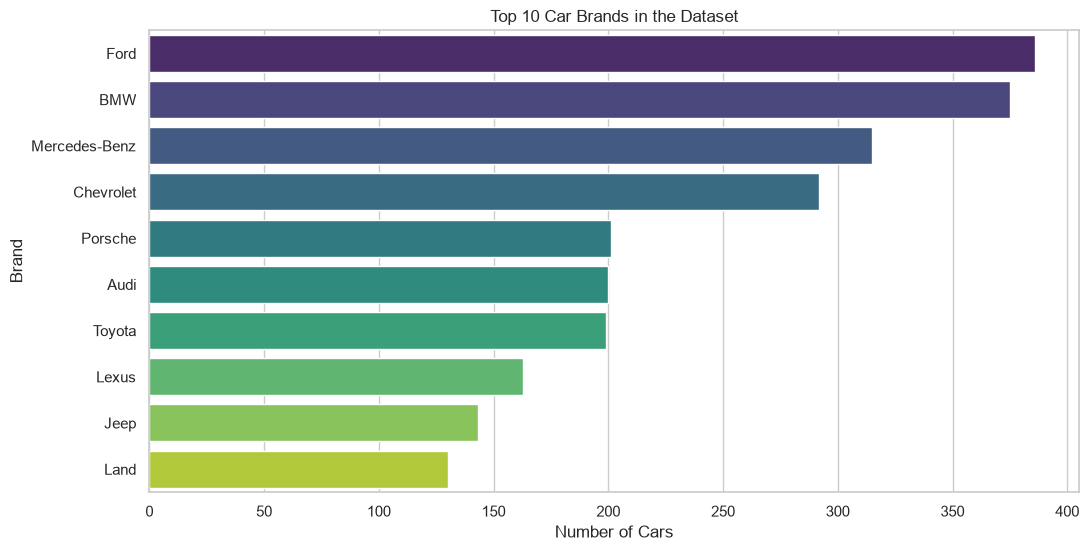

In [97]:
# 6. Top 10 Car Brands in the dataset
plt.figure(figsize=(12, 6))
top_brands = df['brand'].value_counts().head(10)

sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')
plt.title('Top 10 Car Brands in the Dataset')
plt.xlabel('Number of Cars')
plt.ylabel('Brand')
plt.show()

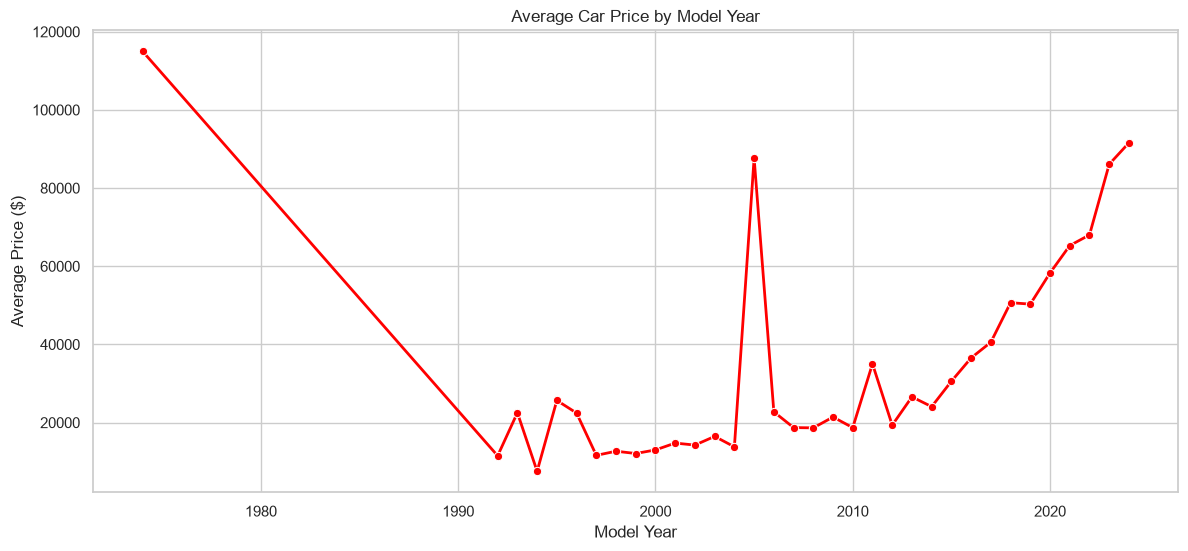

In [98]:
# 7. Average Price by Model Year
plt.figure(figsize=(14, 6))

# Calculate average price for each year
avg_price_year = df.groupby('model_year')['price'].mean().reset_index()

sns.lineplot(x='model_year', y='price', data=avg_price_year, marker='o', color='red', linewidth=2)
plt.title('Average Car Price by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Price ($)')
plt.grid(True)
plt.show()

In [99]:
# ==========================================
# Data Preprocessing
# ==========================================

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     4009 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      4009 non-null   str  
 10  clean_title   4009 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 376.0 KB


In [101]:
df.head(1)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300


In [102]:
# ==========================================
# 1. فحص ومعالجة القيم المفقودة (Missing Values)
# ==========================================

# فحص لو فيه أي خلايا فاضية في الداتا الأصلية
print("Missing values before cleaning:\n", df.isnull().sum())

# أخذ نسخة من الداتا وحذف الصفوف التي تحتوي على قيم مفقودة لتفادي الأخطاء
df_model = df.dropna().copy()

print(f"Data shape after handling missing values: {df_model.shape}")

Missing values before cleaning:
 brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64
Data shape after handling missing values: (4009, 12)


In [103]:
# ==========================================
# 4. Data Preprocessing & Outlier Treatment
# ==========================================
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# 1. تحويل النصوص لأرقام (Encoding)
encoder = LabelEncoder()
categorical_cols = df_model.select_dtypes(include=['object', 'string']).columns
for col in categorical_cols:
    df_model[col] = encoder.fit_transform(df_model[col].astype(str))

# 2. معالجة القيم الشاذة (Outlier Treatment using IQR)
# هنطبق المعالجة على أهم عمودين: السعر (price) والمسافة (milage)
for col in ['price', 'milage']:
    Q1 = df_model[col].quantile(0.25) # الربع الأول
    Q3 = df_model[col].quantile(0.75) # الربع الثالث
    IQR = Q3 - Q1                     # المدى
    lower_bound = Q1 - 1.5 * IQR      # الحد الأدنى
    upper_bound = Q3 + 1.5 * IQR      # الحد الأقصى
    
    # الاحتفاظ بالبيانات الطبيعية فقط وحذف الشواذ
    df_model = df_model[(df_model[col] >= lower_bound) & (df_model[col] <= upper_bound)]

print(f"Data shape after outlier treatment and encoding: {df_model.shape}")

Data shape after outlier treatment and encoding: (3700, 12)


In [104]:
# ==========================================
# 5. Data Splitting & Feature Scaling
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# فصل المدخلات عن الهدف (السعر)
X = df_model.drop('price', axis=1)
y = df_model['price']

# تقسيم البيانات لتدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# توحيد مقياس البيانات
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling completed successfully!")

Data splitting and scaling completed successfully!


In [105]:
# ==========================================
# 6. Building Machine Learning Models
# ==========================================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# تدريب نموذج الانحدار الخطي
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# تدريب نموذج الغابات العشوائية
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print("Models trained successfully!")

Models trained successfully!


--- Linear Regression ---
Mean Absolute Error (MAE): $9151.04
Accuracy (R2 Score): 67.67%

--- Random Forest ---
Mean Absolute Error (MAE): $6338.44
Accuracy (R2 Score): 82.14%



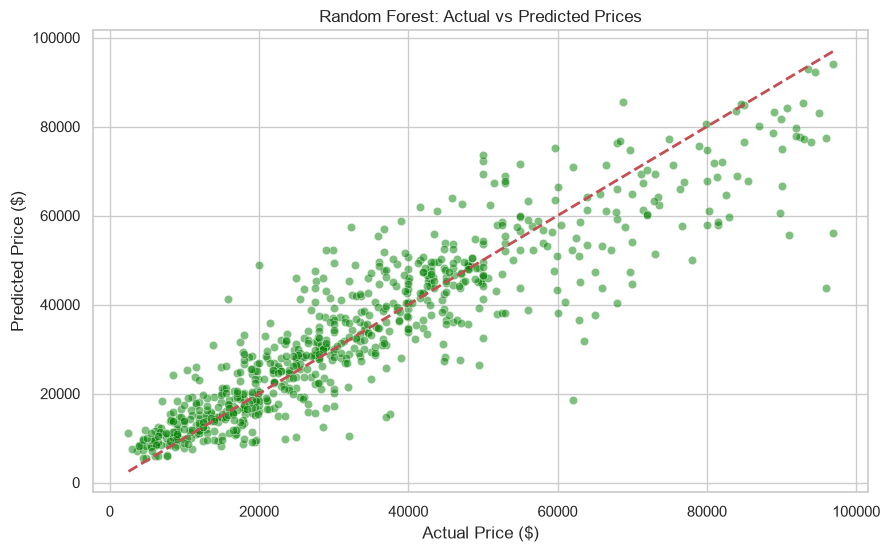

In [106]:
# ==========================================
# 7. Model Evaluation
# ==========================================
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Linear Regression ---")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, lr_pred):.2f}")
print(f"Accuracy (R2 Score): {r2_score(y_test, lr_pred)*100:.2f}%\n")

print("--- Random Forest ---")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, rf_pred):.2f}")
print(f"Accuracy (R2 Score): {r2_score(y_test, rf_pred)*100:.2f}%\n")

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=rf_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.grid(True)
plt.show()